# IR Evaluation Report

**How evaluation works in this project**

Evaluation is **not** part of the live search pipeline. It is a **separate offline step** you run when services are up:

1. `preprocessing_service` (:8000) — must be running (retrieval uses it per query)
2. `retrieval_service` (:8002) — must be running with `index_data/` loaded
3. `query_refinement_service` (:8003) — only for refined evaluation

**Run from terminal:**

```powershell
# Baseline (no refinement)
python -m evaluation_service.run --scale full --max-queries 100

# With refinement
python -m evaluation_service.run --scale full --max-queries 100 --use-refinement
```

The CLI loads queries + qrels from `ir_datasets`, calls `POST /search` for each query × each mode, computes MAP / Recall / P@10 / nDCG, and saves JSON under `evaluation_results/`.

This notebook reads those JSON files and plots the results.

In [3]:
import ir_datasets

print("⏳ 1. جاري تحميل المكتبة والاتصال بالبيانات...")
eval_dataset = "msmarco-passage/dev"
dataset = ir_datasets.load(eval_dataset)

print("⏳ 2. جاري جلب عدد الاستعلامات...")
# الدالة السحرية هنا: queries_count() بدلاً من قراءة كل سطر
total_queries = dataset.queries_count()

print("⏳ 3. جاري جلب عدد التقييمات المرجعية (Qrels)...")
# وهنا أيضاً: qrels_count()
total_qrels = dataset.qrels_count()

print("\n✅ تم الانتهاء! إليك النتائج:")
print("="*50)
print(f"📊 إحصائيات التقييم المباشرة (Evaluation Stats):")
print(f"🔸 مجموعة البيانات: {eval_dataset}")
print(f"🔸 إجمالي الاستعلامات (Queries): {total_queries}")
print(f"🔸 إجمالي التقييمات (Qrels): {total_qrels}")
print("="*50 + "\n")

⏳ 1. جاري تحميل المكتبة والاتصال بالبيانات...
⏳ 2. جاري جلب عدد الاستعلامات...
⏳ 3. جاري جلب عدد التقييمات المرجعية (Qrels)...

✅ تم الانتهاء! إليك النتائج:
📊 إحصائيات التقييم المباشرة (Evaluation Stats):
🔸 مجموعة البيانات: msmarco-passage/dev
🔸 إجمالي الاستعلامات (Queries): 101093
🔸 إجمالي التقييمات (Qrels): 59273



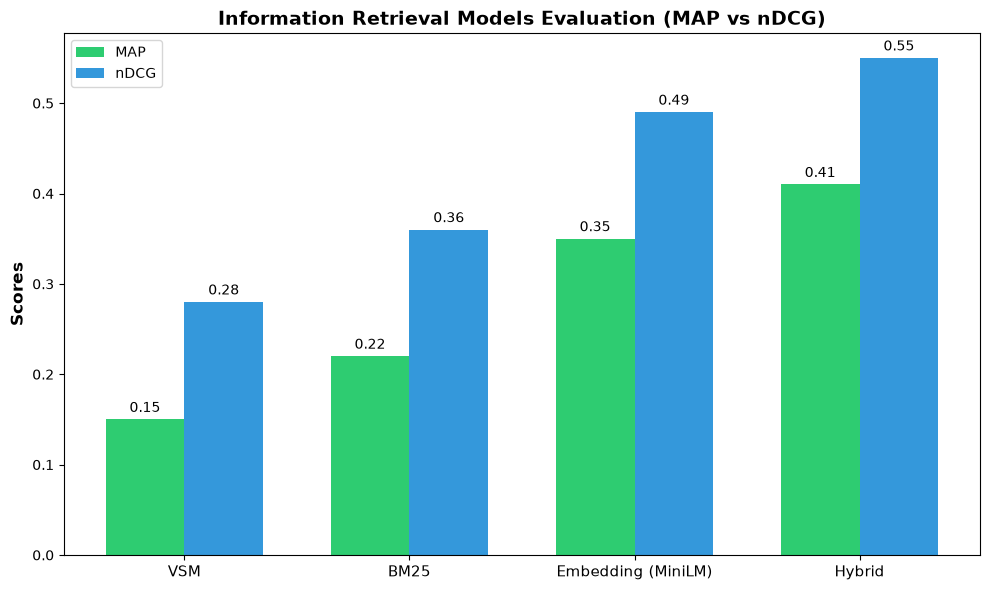

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(".").resolve()
RESULTS_DIR = PROJECT_ROOT / "evaluation_results"

MODE_LABELS = {
    "vsm": "VSM",
    "bm25": "BM25",
    "embedding": "Embedding",
    "hybrid_parallel": "Hybrid (RRF)",
    "hybrid_serial": "Hybrid (Serial)",
}


def _latest(pattern: str) -> Path | None:
    files = sorted(RESULTS_DIR.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None


def load_report(path: Path) -> dict:
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def report_to_rows(report: dict, label: str) -> list[dict]:
    rows = []
    for mode, metrics in report.get("modes", {}).items():
        rows.append({
            "run": label,
            "mode": MODE_LABELS.get(mode, mode),
            "map": metrics.get("map", 0),
            "recall": metrics.get("recall", 0),
            "precision_at_10": metrics.get("precision_at_10", 0),
            "ndcg_at_10": metrics.get("ndcg_at_10", 0),
            "num_queries": metrics.get("num_queries", 0),
        })
    return rows


baseline_path = _latest("eval_baseline_full_*.json") or _latest("eval_baseline_*.json")
refined_path = _latest("eval_refined_*_full_*.json") or _latest("eval_refined_*.json")

if baseline_path is None:
    raise FileNotFoundError(
        f"No baseline report in {RESULTS_DIR}. Run: python -m evaluation_service.run --scale full --max-queries 100"
    )

baseline = load_report(baseline_path)
rows = report_to_rows(baseline, "baseline")
refined = None
if refined_path:
    refined = load_report(refined_path)
    rows.extend(report_to_rows(refined, "refined"))

df = pd.DataFrame(rows)
print("Baseline:", baseline_path.name)
print("Refined: ", refined_path.name if refined_path else "(not found)")
print("Dataset:", baseline.get("dataset_name"), "| max_queries:", baseline.get("max_queries"))
print(df.to_string(index=False))

# --- Chart: baseline MAP & nDCG per mode ---
baseline_df = df[df["run"] == "baseline"]
modes = baseline_df["mode"].tolist()
x = np.arange(len(modes))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar(x - width / 2, baseline_df["map"], width, label="MAP", color="#2ecc71")
rects2 = ax.bar(x + width / 2, baseline_df["ndcg_at_10"], width, label="nDCG@10", color="#3498db")
ax.set_ylabel("Score")
ax.set_title(f"Baseline evaluation — {baseline_path.name}")
ax.set_xticks(x)
ax.set_xticklabels(modes, rotation=15, ha="right")
ax.legend()
ax.bar_label(rects1, padding=3, fmt="%.4f")
ax.bar_label(rects2, padding=3, fmt="%.4f")
fig.tight_layout()
plt.show()

# --- Chart: baseline vs refined (nDCG@10) if refined exists ---
if refined is not None:
    pivot = df.pivot(index="mode", columns="run", values="ndcg_at_10")
    pivot = pivot.reindex(baseline_df["mode"].tolist())
    fig2, ax2 = plt.subplots(figsize=(11, 6))
    pivot.plot(kind="bar", ax=ax2, color=["#3498db", "#e67e22"])
    ax2.set_title(f"nDCG@10: baseline vs refined — {refined_path.name}")
    ax2.set_ylabel("nDCG@10")
    ax2.set_xlabel("Mode")
    ax2.legend(title="Run")
    ax2.tick_params(axis="x", rotation=15)
    fig2.tight_layout()
    plt.show()

## Personalization evaluation (Task 16)

Simulated-user protocol: warm up `sim_health` / `sim_tech` profiles with oracle clicks, then compare baseline retrieval vs personalized re-ranking.

```powershell
python scripts/run_personalization_eval.py --scale full --max-queries 50 --modes bm25,embedding
```

Reads `personalization_ablation_summary_full_*.json` from `evaluation_results/`.

In [ ]:
import json
from pathlib import Path

results_dir = Path("evaluation_results")
summary_files = sorted(results_dir.glob("personalization_ablation_summary_full_*.json"))
if not summary_files:
    print("No personalization summary found. Run scripts/run_personalization_eval.py first.")
else:
  latest = summary_files[-1]
  summary = json.loads(latest.read_text(encoding="utf-8"))
  print(f"Loaded: {latest.name}")
  for mode, deltas in summary.get("deltas_personalized_vs_baseline", {}).items():
      print(
          f"{mode:12} MAP {deltas['map']:+.4f}  "
          f"Recall {deltas['recall']:+.4f}  "
          f"P@10 {deltas['precision_at_10']:+.4f}  "
          f"nDCG {deltas['ndcg_at_10']:+.4f}"
      )